У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_score, recall_score
from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

In [2]:
raw_df = pd.read_csv('customer_segmentation_train.csv')
raw_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [3]:
raw_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               8068 non-null   int64  
 1   Gender           8068 non-null   object 
 2   Ever_Married     7928 non-null   object 
 3   Age              8068 non-null   int64  
 4   Graduated        7990 non-null   object 
 5   Profession       7944 non-null   object 
 6   Work_Experience  7239 non-null   float64
 7   Spending_Score   8068 non-null   object 
 8   Family_Size      7733 non-null   float64
 9   Var_1            7992 non-null   object 
 10  Segmentation     8068 non-null   object 
dtypes: float64(2), int64(2), object(7)
memory usage: 693.5+ KB


In [4]:
def calculate_null_percentages(df):
    null_count = df.isnull().sum()
    null_percentage = round((df.isnull().sum()/df.shape[0])*100, 4)
    null_df = pd.DataFrame({'column_name' : df.columns,'null_count' : null_count,'null_percentage': null_percentage})
    null_df.reset_index(drop = True, inplace = True)
    null_df.sort_values(by = 'null_percentage', ascending = False, inplace = True)
    display(null_df)
calculate_null_percentages(raw_df)

,column_name,null_count,null_percentage
6,Work_Experience,829,10.2752
8,Family_Size,335,4.1522
2,Ever_Married,140,1.7353
5,Profession,124,1.5369
4,Graduated,78,0.9668
9,Var_1,76,0.9420
0,ID,0,0.0000
1,Gender,0,0.0000
3,Age,0,0.0000
7,Spending_Score,0,0.0000


In [5]:
cols_to_impute = raw_df.columns[raw_df.isnull().any()]
for col in cols_to_impute:
    print(raw_df[col].value_counts())

Ever_Married
Yes    4643
No     3285
Name: count, dtype: int64
Graduated
Yes    4968
No     3022
Name: count, dtype: int64
Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
Name: count, dtype: int64
Work_Experience
1.0     2354
0.0     2318
9.0      474
8.0      463
2.0      286
3.0      255
4.0      253
6.0      204
7.0      196
5.0      194
10.0      53
11.0      50
12.0      48
13.0      46
14.0      45
Name: count, dtype: int64
Family_Size
2.0    2390
3.0    1497
1.0    1453
4.0    1379
5.0     612
6.0     212
7.0      96
8.0      50
9.0      44
Name: count, dtype: int64
Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
Name: count, dtype: int64


In [6]:
target_col = 'Segmentation'
input_cols = [col for col in raw_df.columns if col != target_col]
inputs, target = raw_df[input_cols], raw_df[target_col]

train_inputs, val_inputs, train_target, val_target = train_test_split(
    inputs, target, test_size=0.2, random_state=42, stratify=target
)

num_cols = train_inputs.select_dtypes(include=np.number).columns.difference(['ID'])

cat_cols_ordinal = ['Gender', 'Ever_Married', 'Graduated', 'Spending_Score']
cat_cols_one_hot = ['Profession', 'Var_1']
cat_cols_all = train_inputs.select_dtypes(include='object').columns.tolist()

assert set(cat_cols_ordinal + cat_cols_one_hot) == set(cat_cols_all), "Mismatch in categorical columns!"

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('scaler', MinMaxScaler())
])

cat_ord_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=[
        ['Female', 'Male'],    # for Gender column, Female=0, Male=1
        ['No', 'Yes'],         # for Ever_Married column, No=0, Yes=1
        ['No', 'Yes'],         # for Graduated column, No=0, Yes=1
        ['Low', 'Average', 'High'] # for Spending_Score
    ]))
])

cat_oh_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat_ord', cat_ord_transformer, cat_cols_ordinal),
        ('cat_oh', cat_oh_transformer, cat_cols_one_hot)
    ])
preprocessor.set_output(transform='pandas')

train_processed = preprocessor.fit_transform(train_inputs)
val_processed = preprocessor.transform(val_inputs)
val_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1614 entries, 6862 to 514
Data columns (total 23 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   num__Age                          1614 non-null   float64
 1   num__Family_Size                  1614 non-null   float64
 2   num__Work_Experience              1614 non-null   float64
 3   cat_ord__Gender                   1614 non-null   float64
 4   cat_ord__Ever_Married             1614 non-null   float64
 5   cat_ord__Graduated                1614 non-null   float64
 6   cat_ord__Spending_Score           1614 non-null   float64
 7   cat_oh__Profession_Artist         1614 non-null   float64
 8   cat_oh__Profession_Doctor         1614 non-null   float64
 9   cat_oh__Profession_Engineer       1614 non-null   float64
 10  cat_oh__Profession_Entertainment  1614 non-null   float64
 11  cat_oh__Profession_Executive      1614 non-null   float64
 12  cat_oh__P

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [7]:
cat_indices = list(range(3, 23)) # з .info() output попереднього завдання

In [8]:
smotenc = SMOTENC(random_state=0, categorical_features=cat_indices)
smotetomek = SMOTETomek(smote=smotenc, random_state=0)

X_train_smotenc, y_train_smotenc = smotenc.fit_resample(train_processed, train_target)
X_train_smotetomek, y_train_smotetomek = smotetomek.fit_resample(train_processed, train_target)

train_target.value_counts(), y_train_smotetomek.value_counts(), y_train_smotenc.value_counts()

(Segmentation
 D    1814
 A    1578
 C    1576
 B    1486
 Name: count, dtype: int64,
 Segmentation
 C    1474
 D    1444
 B    1409
 A    1381
 Name: count, dtype: int64,
 Segmentation
 A    1814
 B    1814
 C    1814
 D    1814
 Name: count, dtype: int64)

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

Report for Processed Data
              precision    recall  f1-score   support

           A       0.41      0.44      0.43       394
           B       0.41      0.15      0.21       372
           C       0.48      0.64      0.55       394
           D       0.64      0.75      0.69       454

    accuracy                           0.51      1614
   macro avg       0.49      0.50      0.47      1614
weighted avg       0.49      0.51      0.48      1614



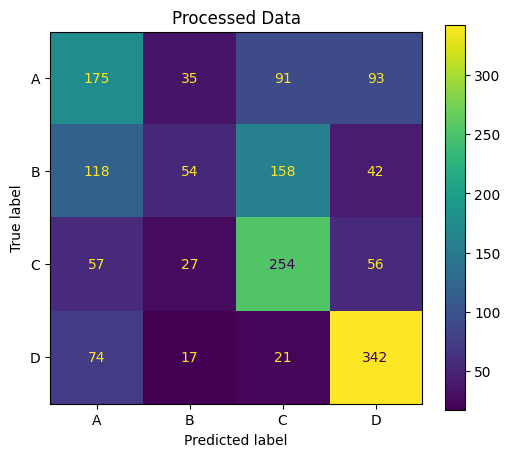

Report for SMOTE Balanced Data
              precision    recall  f1-score   support

           A       0.42      0.49      0.45       394
           B       0.42      0.21      0.28       372
           C       0.50      0.61      0.55       394
           D       0.67      0.71      0.69       454

    accuracy                           0.52      1614
   macro avg       0.50      0.51      0.49      1614
weighted avg       0.51      0.52      0.50      1614



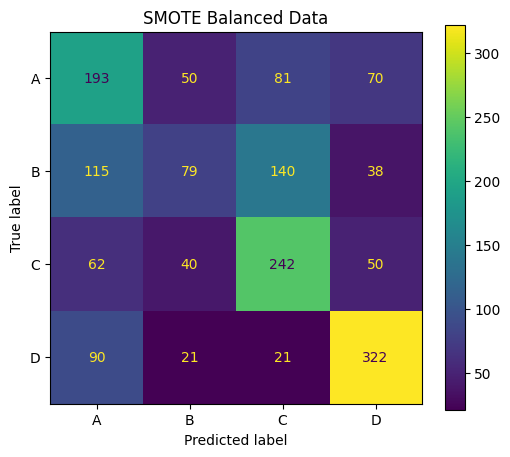

Report for SMOTE-Tomek Balanced Data
              precision    recall  f1-score   support

           A       0.42      0.50      0.46       394
           B       0.41      0.19      0.26       372
           C       0.49      0.61      0.54       394
           D       0.68      0.70      0.69       454

    accuracy                           0.51      1614
   macro avg       0.50      0.50      0.49      1614
weighted avg       0.51      0.51      0.50      1614



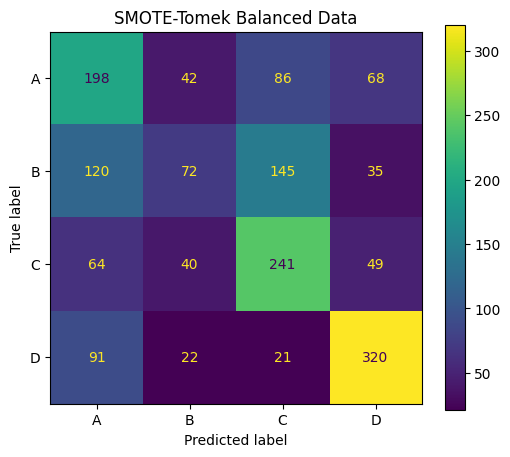

In [9]:
def report(X_train, y_train, X_test, y_test, title):
    print(f"Report for {title}")
    
    ovr = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
    ovr.fit(X_train, y_train)
    y_test_pred = ovr.predict(X_test)
    
    print(classification_report(y_test, y_test_pred))
    
    fig, ax = plt.subplots(figsize=(6, 5))
    ConfusionMatrixDisplay.from_predictions(y_test, y_test_pred, ax=ax)
    ax.set_title(title)
    plt.show()

report(train_processed, train_target, val_processed, val_target, 'Processed Data')
report(X_train_smotenc, y_train_smotenc, val_processed, val_target, 'SMOTE Balanced Data')
report(X_train_smotetomek, y_train_smotetomek, val_processed, val_target, 'SMOTE-Tomek Balanced Data');

Як основну метрику я взяла marco-averaged F1, оскільки вона враховує всі класи однаково, незалежно від їх розміру. Бачимо, що в обох моделях з ресамплінгом маємо незначне покращення (0.49 порівняно з 0.47 без ресамплінгу)

Чому результати практично не відрізняються?
- можливо, через те, що в початкових даних не було яскраво вираженого дизбалансу (D - 1814, A - 1578, C - 1576, B - 1486 для тренувальних даних, відмінності не настільки великі) - отож балансування не дає відчутного результату
- також в нас дуже погані метрики передбачення для класу В (для наглядності побудувала також Confusion Matrixes) - треба більше розібратися і дослідити цей клас, можливо він має багато спільного з класом А і С, бо всі моделі частіше вибирають ці класи як мітку.

Спробувала візуалізувати також за допомогою decision boundaries - можливо я десь допустила помилку, але це не дуже допомогло :) Можна лиш сказати, що всі моделі справляються не дуже добре.

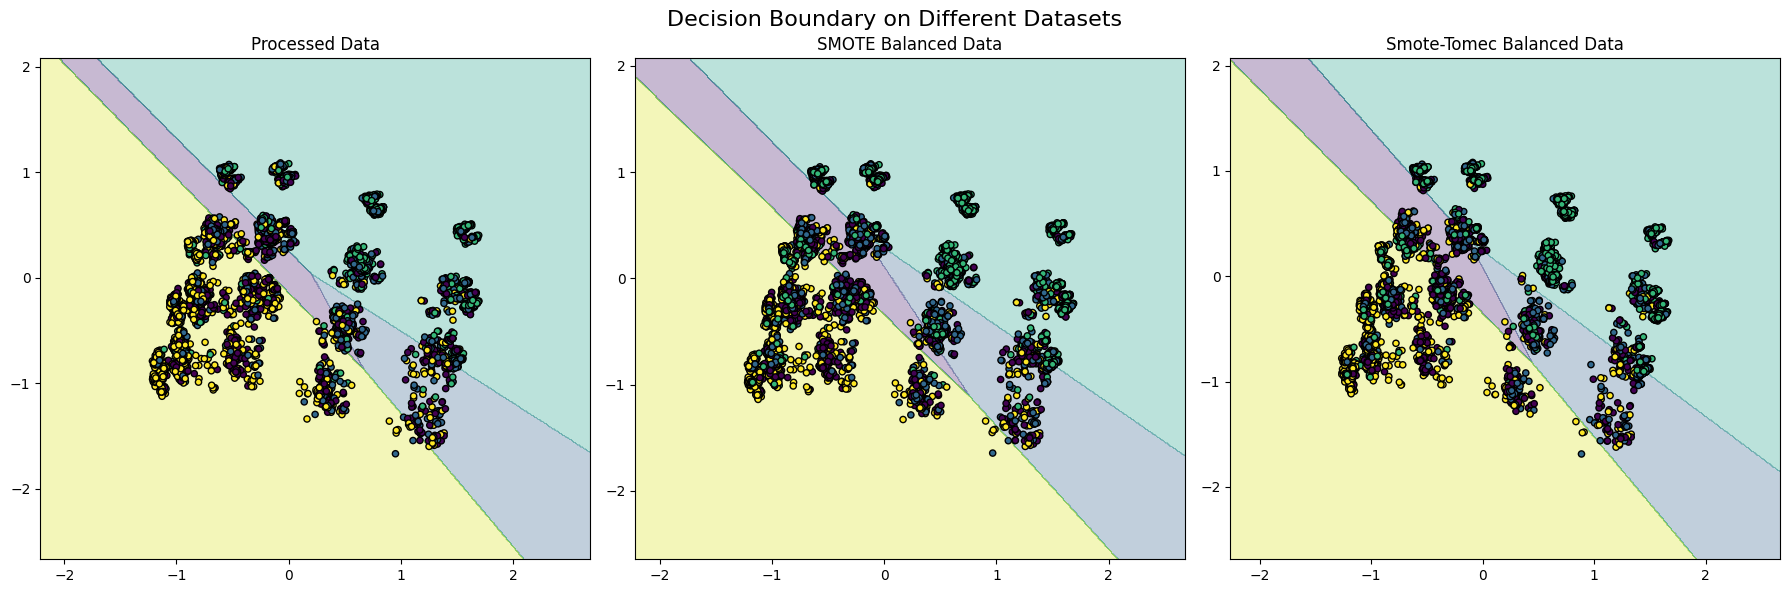

In [10]:
def plot_decision_boundaries(X_train, y, ax, title):
    pca = PCA(n_components=2)
    X = pca.fit_transform(X_train)
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    ovr = OneVsRestClassifier(LogisticRegression(solver='liblinear'))
    ovr.fit(X, y_encoded)
    Z = ovr.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y_encoded, edgecolor='k', marker='o', s=20)
    ax.set_title(title)
    return scatter

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

plot_decision_boundaries(train_processed, train_target, axes[0], "Processed Data")
plot_decision_boundaries(X_train_smotenc, y_train_smotenc, axes[1], "SMOTE Balanced Data")
plot_decision_boundaries(X_train_smotetomek, y_train_smotetomek, axes[2], "Smote-Tomec Balanced Data")

fig.suptitle('Decision Boundary on Different Datasets', fontsize=16)
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()